## GRPO Math500

In [34]:
from datasets import load_dataset
import json
import argparse
import re
import os
from collections import defaultdict
from typing import List

data_name = "grpo_math500"

ds_grpo = []
for i in range(2, 6):
    data_path = os.path.expanduser(f"~/PRM_filter/eval/eval_prm/data/{data_name}_{i}.jsonl")
    ds0 = load_dataset("json", data_files=data_path, split="train")
    ds_grpo.append(ds0)

print(len(ds_grpo))

4


In [35]:
pro_data_list_grpo = []

for i in range(len(ds_grpo[0])):
    problem = ds_grpo[0][i]["source"]["problem"]
    steps = ds_grpo[0][i]["source"]["steps"]
    solution = ds_grpo[0][i]["source"]["solution"]
    score = ds_grpo[0][i]["source"]["score"]
    judge = [ds_grpo[j][i]["synthetic"]["inference"] for j in range(len(ds_grpo))]

    pro_data_list_grpo.append({
        "problem": problem,
        "steps": steps,
        "solution": solution,
        "score": score,
        "judge": judge
    })

pro_data_list_grpo[0]

{'problem': 'Five points $A$, $B$, $C$, $D$, and $O$ lie on a flat field.  $A$ is directly north of $O$, $B$ is directly west of $O$, $C$ is directly south of $O$, and $D$ is directly east of $O$. The  distance between $C$ and $D$ is 140 m.  A hot-air balloon is positioned in the air at $H$ directly above $O$. The balloon is held in place by four ropes $HA$, $HB$, $HC$, and $HD$.  Rope $HC$ has length 150 m and rope $HD$ has length 130 m. [asy]\nsize(250);\npair A, B, C, D, O, H, W, X, Y, Z;\nO=(0,0);\nA=(1,1);\nD=(1.5,-.3);\nB=(-1.5,.3);\nC=(-1,-1);\nH=(0,2.5);\nW=(5/3)*(A+D);\nX=(5/3)*(A+B);\nY=(-1)*(W);\nZ=(-1)*(X);\ndraw(W--X--Y--Z--W);\ndraw(A--C);\ndraw(B--D);\ndraw(O--H, linewidth(1));\ndraw(A--H, dashed);\ndraw(B--H, dashed);\ndraw(C--H, dashed);\ndraw(D--H, dashed);\ndot(A);\ndot(B);\ndot(C);\ndot(D);\ndot(O);\ndot(H);\nlabel("A", A, NE);\nlabel("B", B, SW);\nlabel("C", C, SE);\nlabel("D", D, NE);\nlabel("O", O, SE);\nlabel("H", H, NW);\n[/asy]\n\nTo reduce the total length of

In [36]:
def extract_boxed_labels(text: str) -> List[int]:
    """
    Finds all instances of \\boxed{CORRECT} or \\boxed{INCORRECT} in a string,
    case-insensitively, and converts them to a list of 1s and 0s respectively.
    """
    if not isinstance(text, str):
        return []
    text = re.sub(r'\\boxed{(PARTIAL|PARTIALLY CORRECT|Incomplete|CANNOT VERIFY)}', r'\\boxed{INCORRECT}', text)
    text = re.sub(r'\\boxed{(\\checkmark|\u2713)}', r'\\boxed{CORRECT}', text)
    
    matches = re.findall(r'\\boxed\{\s*(CORRECT|INCORRECT)\s*\}', text, flags=re.IGNORECASE)
    judges = [1 if m.upper() == "CORRECT" else 0 for m in matches]
    return judges

judges = []
for i in range(len(pro_data_list_grpo)):
    judge = []
    for j in range(len(pro_data_list_grpo[i]["judge"])):
        judge_txt = pro_data_list_grpo[i]["judge"][j]
        judge_score = extract_boxed_labels(judge_txt)
        if judge_score==[]:
            continue
        judge.append(judge_score)
    judges.append(judge)

print(len(judges))
print(judges[0])


500
[[1, 0, 0, 0, 0, 0, 0], [1, 1, 1], [1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1]]


In [37]:
flag=0
for i in range(len(pro_data_list_grpo)):
    steps = pro_data_list_grpo[i]["steps"]
    correct_judge = None
    for j in range(len(judges[i])):
        if len(judges[i][j])==steps:
            correct_judge = judges[i][j]
            break
    if correct_judge is None:
        flag+=1
        correct_judge = [0]

    pro_data_list_grpo[i]["correct_judge"] = correct_judge


print(flag)

68


In [38]:
import numpy as np

acc_judge = []
acc_min = []
acc_pos = []
acc_neg = []
for i in range(len(pro_data_list_grpo)):
    acc_judge.append(np.mean(pro_data_list_grpo[i]['correct_judge']))
    if pro_data_list_grpo[i]['score'] == 1:
        acc_min.append(np.min(pro_data_list_grpo[i]['correct_judge']))
        acc_pos.append(np.mean(pro_data_list_grpo[i]['correct_judge']))
    else:
        acc_neg.append(np.mean(pro_data_list_grpo[i]['correct_judge']))

In [39]:
print("acc:", len(acc_judge)/len(pro_data_list_grpo))
print("mean prm:", np.mean(acc_judge))
print("pos min prm:", np.mean(acc_min))
print("pos:", np.mean(acc_pos))
print("neg:", np.mean(acc_neg))

acc: 1.0
mean prm: 0.7955797783152622
pos min prm: 0.8992248062015504
pos: 0.9216609437352122
neg: 0.3637796808150791


In [40]:
## mean step number
step_num_grpo = [pro_data_list_grpo[i]['steps'] for i in range(len(pro_data_list_grpo))]
print("mean step num:", np.mean(step_num_grpo))

mean step num: 7.308


In [43]:
pro_data_list_grpo[167]

{'problem': "Define\n\\[p = \\sum_{k = 1}^\\infty \\frac{1}{k^2} \\quad \\text{and} \\quad q = \\sum_{k = 1}^\\infty \\frac{1}{k^3}.\\]Find a way to write\n\\[\\sum_{j = 1}^\\infty \\sum_{k = 1}^\\infty \\frac{1}{(j + k)^3}\\]in terms of $p$ and $q.$ Let's think step by step and output the final answer within \\boxed{}.",
 'steps': 2,
 'solution': "<step>We need to find the value of the double sum \\(\\sum_{j=1}^\\infty \\sum_{k=1}^\\infty \\frac{1}{(j+k)^3}\\) in terms of \\(p\\) and \\(q\\), where \\(p = \\sum_{k=1}^\\infty \\frac{1}{k^2}\\) and \\(q = \\sum_{k=1}^\\infty \\frac{1}{k^3}\\).</step>\n<step>First, let's rewrite the double sum in a more convenient form. We can change the indices of the sum to make it easier to handle. Let \\(n = j + k\\). Then for each fixed \\(n\\), \\(j\\) can range from 1 to \\(n-1\\) and \\(k = n - j\\). So the double sum can be rewritten as:\n\\[\n\\sum_{n=2}^\\infty \\sum_{j=1}^{n-1} \\frac{1}{n^3} = \\sum_{n=2}^\\infty \\frac{n-1}{n^3} = \\sum_{n=

## Qwen PRM Math500

In [26]:
from datasets import load_dataset
import json
import argparse
import re
import os
from collections import defaultdict
from typing import List

data_name = "prm_math500"

ds = []
for i in range(2, 6):
    data_path = os.path.expanduser(f"~/PRM_filter/eval/eval_prm/data/{data_name}_{i}.jsonl")
    ds0 = load_dataset("json", data_files=data_path, split="train")
    ds.append(ds0)

print(len(ds))

4


In [27]:
pro_data_list = []

for i in range(len(ds[0])):
    problem = ds[0][i]["source"]["problem"]
    steps = ds[0][i]["source"]["steps"]
    solution = ds[0][i]["source"]["solution"]
    score = ds[0][i]["source"]["score"]
    judge = [ds[j][i]["synthetic"]["inference"] for j in range(len(ds))]

    pro_data_list.append({
        "problem": problem,
        "steps": steps,
        "solution": solution,
        "score": score,
        "judge": judge
    })

pro_data_list[0]

{'problem': "Let $a$ and $b$ be positive real numbers such that $ab^2 = 5.$  Find the minimum value of $a^4 + b^8.$ Let's think step by step and output the final answer within \\boxed{}.",
 'steps': 8,
 'solution': "<step>We need to find the minimum value of \\(a^4 + b^8\\) given that \\(ab^2 = 5\\).</step>\n<step>First, we express \\(a\\) in terms of \\(b\\) using the constraint \\(ab^2 = 5\\):\n\\[a = \\frac{5}{b^2}.\\]</step>\n<step>Next, we substitute this expression for \\(a\\) into the expression \\(a^4 + b^8\\):\n\\[a^4 + b^8 = \\left(\\frac{5}{b^2}\\right)^4 + b^8 = \\frac{625}{b^8} + b^8.\\]</step>\n<step>Let \\(x = b^8\\). Then the expression becomes:\n\\[f(x) = \\frac{625}{x} + x.\\]</step>\n<step>To find the minimum value of \\(f(x)\\), we take the derivative and set it to zero:\n\\[f'(x) = -\\frac{625}{x^2} + 1.\\]\nSetting \\(f'(x) = 0\\):\n\\[1 - \\frac{625}{x^2} = 0 \\implies x^2 = 625 \\implies x = 25 \\quad (\\text{since } x = b^8 > 0).\\]</step>\n<step>Now we substit

In [28]:
judges = []
for i in range(len(pro_data_list)):
    judge = []
    for j in range(len(pro_data_list[i]["judge"])):
        judge_txt = pro_data_list[i]["judge"][j]
        judge_score = extract_boxed_labels(judge_txt)
        if judge_score==[]:
            continue
        judge.append(judge_score)
    judges.append(judge)

print(len(judges))
print(judges[0])

flag=0
for i in range(len(pro_data_list)):
    steps = pro_data_list[i]["steps"]
    correct_judge = None
    for j in range(len(judges[i])):
        if len(judges[i][j])==steps:
            correct_judge = judges[i][j]
            break
    if correct_judge is None:
        flag+=1
        correct_judge = [0]

    pro_data_list[i]["correct_judge"] = correct_judge


print(flag)

import numpy as np

acc_judge = []
acc_min = []
acc_pos = []
acc_neg = []
for i in range(len(pro_data_list)):
    acc_judge.append(np.mean(pro_data_list[i]['correct_judge']))
    if pro_data_list[i]['score'] == 1:
        acc_min.append(np.min(pro_data_list[i]['correct_judge']))
        acc_pos.append(np.mean(pro_data_list[i]['correct_judge']))
    else:
        acc_neg.append(np.mean(pro_data_list[i]['correct_judge']))

print("acc:", len(acc_judge)/len(pro_data_list))
print("mean prm:", np.mean(acc_judge))
print("pos min prm:", np.mean(acc_min))
print("pos:", np.mean(acc_pos))
print("neg:", np.mean(acc_neg))

500
[[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
54
acc: 1.0
mean prm: 0.8217877873144402
pos min prm: 0.8883248730964467
pos: 0.9222570154042236
neg: 0.4483455621505289


In [29]:
## mean step number
step_num_prm = [pro_data_list[i]['steps'] for i in range(len(pro_data_list))]
print("mean step num:", np.mean(step_num_prm))

mean step num: 7.91


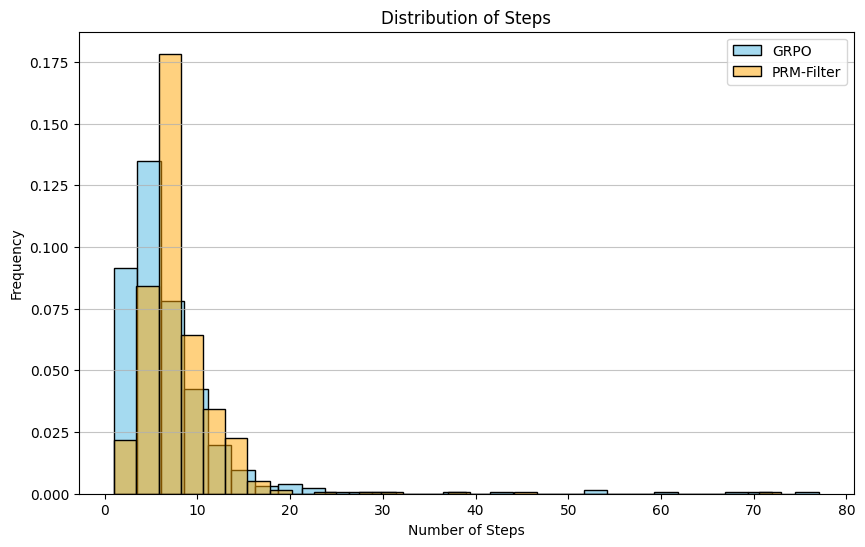

In [30]:
# bar plot
# bar plot of ent_split_steps
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(step_num_grpo, bins=30, kde=False, color='skyblue', stat="density")
sns.histplot(step_num_prm, bins=30, kde=False, color='orange', alpha=0.5, stat="density")
plt.legend(['GRPO', 'PRM-Filter'])
plt.xlabel("Number of Steps")
plt.ylabel("Frequency")
plt.title("Distribution of Steps")
plt.grid(axis='y', alpha=0.75)
plt.show()